# **Section 1. Problem Understanding**

## **Identify the Business Problem** 
By Using Classification whether the Model that predicts the Risk Category of EV users based on their charging habits, energy usage patterns, and financial indicators.


By Using Machine Learning Algorithm we should predict the Accuracy,Precision,F1 Score of Target Variable Risk


### **Importing Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("EV Charging Behavior Dataset.csv")
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


## **Load the Dataset and Identify Basic Checks(Descriptive Analysis)**

In [4]:
df.shape

(18946, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

In [6]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

### **Exploratory Data Analysis**

# **1. UNIVARIATE ANALYSIS (Single Variable)**

## **A) Numerical Columns**

### **Histogram**

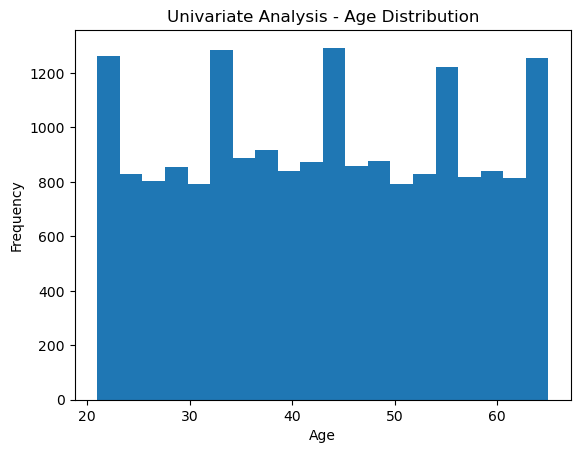

In [7]:
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Univariate Analysis - Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## **B) Categorical Columns**

### **Countplot (Bar Chart)**

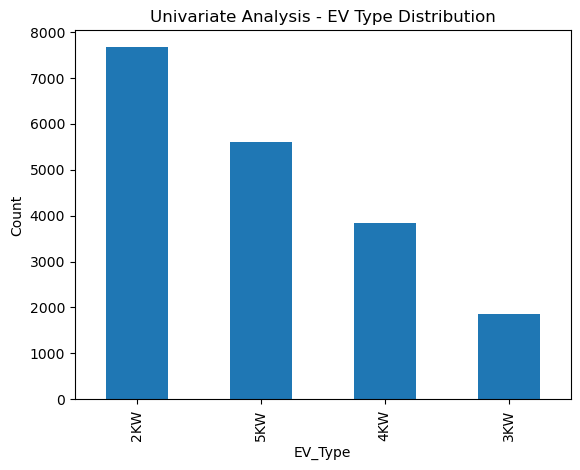

In [8]:
# Categorical Univariate - Income
plt.figure()
df['EV_Type'].value_counts().plot(kind='bar')
plt.title("Univariate Analysis - EV Type Distribution")
plt.xlabel("EV_Type")
plt.ylabel("Count")
plt.show()

# **2. BIVARIATE ANALYSIS (Two Variables)**

## **A) Numerical vs Numerical**

### **Scatter Plot**

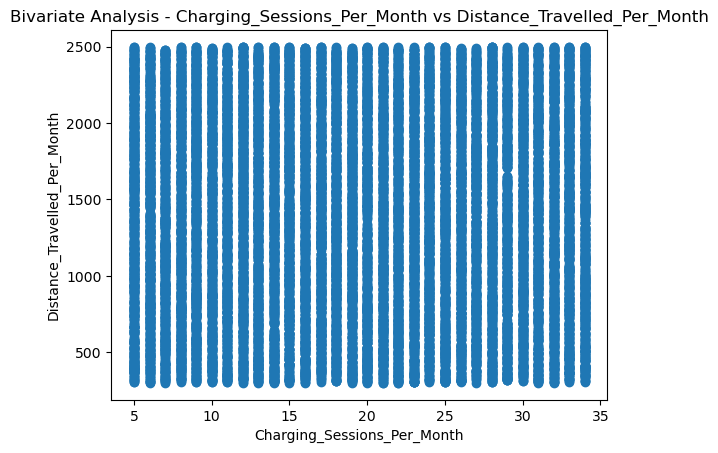

In [9]:
plt.figure()
plt.scatter(df['Charging_Sessions_Per_Month'], df['Distance_Travelled_Per_Month'])
plt.title("Bivariate Analysis - Charging_Sessions_Per_Month vs Distance_Travelled_Per_Month")
plt.xlabel("Charging_Sessions_Per_Month")
plt.ylabel("Distance_Travelled_Per_Month")
plt.show()

## **B) Numerical vs Categorical**

### **Boxplot**

<Figure size 640x480 with 0 Axes>

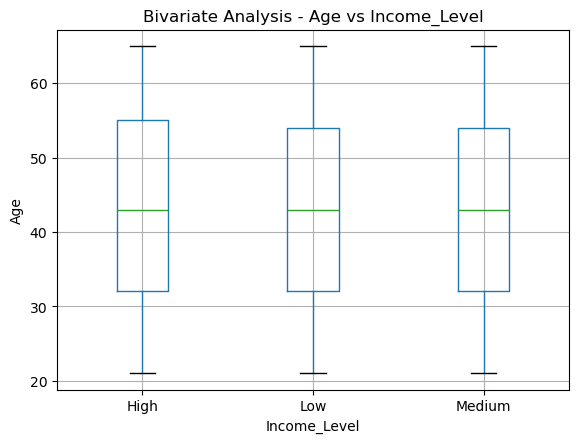

In [10]:
plt.figure()
df.boxplot(column='Age', by='Income_Level')
plt.title("Bivariate Analysis - Age vs Income_Level")
plt.suptitle("")
plt.xlabel("Income_Level")
plt.ylabel("Age")
plt.show()

## **C) Categorical vs Categorical**

### **Count Plot**

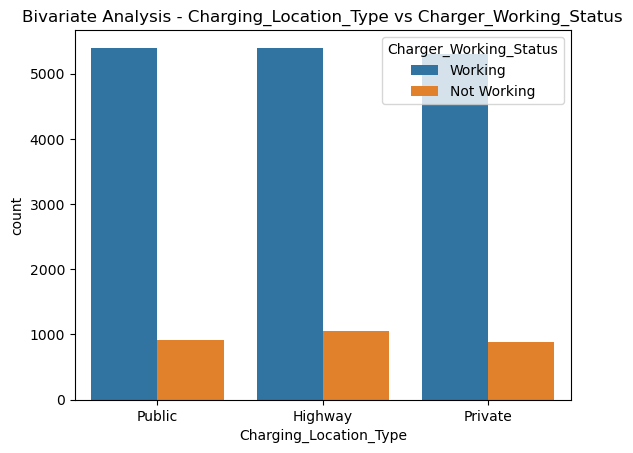

In [11]:
plt.figure()
sns.countplot(x='Charging_Location_Type', hue='Charger_Working_Status', data=df)
plt.title("Bivariate Analysis - Charging_Location_Type vs Charger_Working_Status")
plt.show()

# **MULTIVARIATE ANALYSIS (More than 2 Variables)**

## **A) Correlation Heatmap (Numerical Only)**

In [12]:
num_cols = ["Age","Charging_Sessions_Per_Month","Distance_Travelled_Per_Month","Loan_Taken","Missed_Payments_Last_6M","App_Usage_Score"]

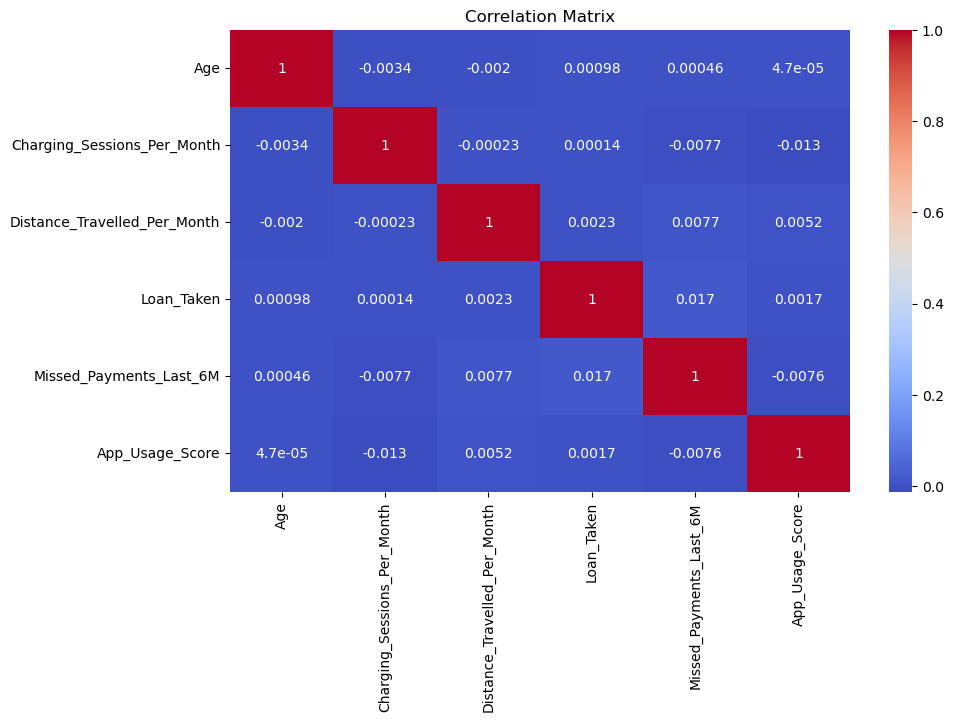

In [13]:
plt.figure(figsize=(10,6))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **B) Pairplot**

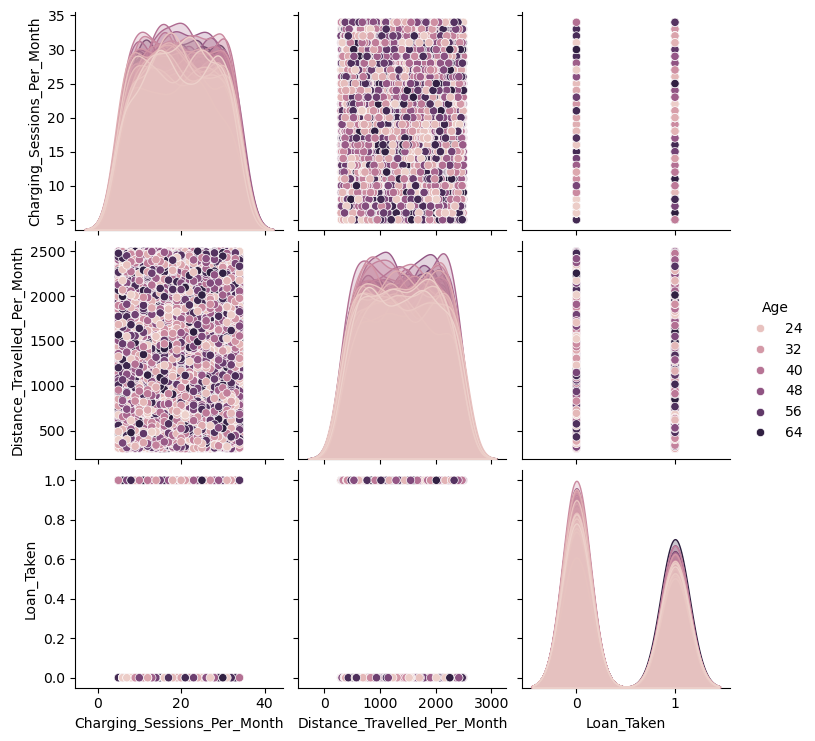

In [14]:
selected_cols = ["Age","Charging_Sessions_Per_Month","Distance_Travelled_Per_Month","Loan_Taken"]

sns.pairplot(df[selected_cols], hue='Age')
plt.show()

# **Section 3 : Preprocessing**

In [15]:
df.duplicated().sum()

0

In [16]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

# Section 4: Feature Engineering

### Define features and target

In [17]:
X = df.drop(columns = ["High_Default_Risk","User_ID","Distance_Travelled_Per_Month","Missed_Payments_Last_6M","Charging_Location_Type"], axis=1)
y = df["High_Default_Risk"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (18946, 13)
Target shape: (18946,)


## Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15156, 13)
Test size: (3790, 13)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          18946 non-null  int64  
 1   City_Tier                    18946 non-null  object 
 2   EV_Type                      18946 non-null  object 
 3   Battery_Capacity_kWh         18946 non-null  float64
 4   Charging_Sessions_Per_Month  18946 non-null  int64  
 5   Avg_Charge_Cost              18946 non-null  float64
 6   Income_Level                 18946 non-null  object 
 7   Loan_Taken                   18946 non-null  int64  
 8   Tenure_Months                18946 non-null  int64  
 9   App_Usage_Score              18946 non-null  int64  
 10  Charger_Working_Status       18946 non-null  object 
 11  Charging_Time_Minutes        18946 non-null  float64
 12  Charging_Efficiency_Index    18946 non-null  float64
dtypes: float64(4), i

### Encoding and Scaling

In [22]:
ts = ColumnTransformer(transformers=[("t1",StandardScaler(),[0,3,4,5,7,8,9,11,12]),
                                     ("t2",OrdinalEncoder(),[1,2,6,10])])

In [23]:
X_transform = ts.fit_transform(X)

In [24]:
X_transform = pd.DataFrame(X_transform,columns = X.columns)

### Feature Selection

In [25]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_transform,y)
mi = pd.Series(mi)
mi.index = X_transform.columns
mi.sort_values(ascending = False)

Tenure_Months                  0.084318
Loan_Taken                     0.073681
Charging_Efficiency_Index      0.073507
Income_Level                   0.064491
Charging_Sessions_Per_Month    0.060002
Charging_Time_Minutes          0.053330
EV_Type                        0.052288
App_Usage_Score                0.005293
Age                            0.004093
City_Tier                      0.002186
Avg_Charge_Cost                0.001205
Battery_Capacity_kWh           0.000000
Charger_Working_Status         0.000000
dtype: float64

In [26]:
X = X.drop(["Battery_Capacity_kWh","Avg_Charge_Cost","App_Usage_Score"],axis =1 )

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          18946 non-null  int64  
 1   City_Tier                    18946 non-null  object 
 2   EV_Type                      18946 non-null  object 
 3   Charging_Sessions_Per_Month  18946 non-null  int64  
 4   Income_Level                 18946 non-null  object 
 5   Loan_Taken                   18946 non-null  int64  
 6   Tenure_Months                18946 non-null  int64  
 7   Charger_Working_Status       18946 non-null  object 
 8   Charging_Time_Minutes        18946 non-null  float64
 9   Charging_Efficiency_Index    18946 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 1.4+ MB


# Section 6 : Model Training & Tuning

In [28]:
X_train_trans = ts.fit_transform(X_train)
X_train_trans = pd.DataFrame(X_train_trans)

In [29]:
X_test_trans = ts.fit_transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
best_params = {
"criterion":("gini", "entropy"),
"splitter":("best", "random"),
"max_depth":(list(range(1, 10))),
"min_samples_split":[2, 3, 4,5,6,7],
"min_samples_leaf":list(range(1, 5)),

}

tree_clf = DecisionTreeClassifier()
tree_cv = RandomizedSearchCV(tree_clf, best_params, scoring="accuracy", n_jobs =- 1, verbose=2, cv=5)

In [31]:
tree_cv.fit(X_train_trans,y_train)   # training data on gridsearch
best_params = tree_cv.best_params_  # it will give you best parameters
print(f"Best paramters: {best_params})") # printing best parameters

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best paramters: {'splitter': 'best', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_depth': 8, 'criterion': 'gini'})


### Model Building(Applying Classification Model)

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion= 'gini',splitter = 'best', min_samples_split =  7, min_samples_leaf =  4, max_depth = 8)

In [33]:
dt.fit(X_train_trans,y_train)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, min_samples_split=7)

In [34]:
y_pred = dt.predict(X_test_trans)

In [35]:
y_train_pred = dt.predict(X_train_trans)

# Section 7 : Model Evaluation

### Evolution Metrics

In [36]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
print("The Train Accuracy for Decision Trees",accuracy_score(y_train_pred,y_train))
print("The Test Accuracy for Decision Trees",accuracy_score(y_pred,y_test))
print("The F1_score for Decision Trees is",f1_score(y_pred,y_test,average="micro"))

The Train Accuracy for Decision Trees 0.8614410134600158
The Test Accuracy for Decision Trees 0.8350923482849604
The F1_score for Decision Trees is 0.8350923482849604


In [37]:
print("The Test Accuracy for Decision Trees",confusion_matrix(y_pred,y_test))

The Test Accuracy for Decision Trees [[1890  412]
 [ 213 1275]]


In [57]:
from sklearn. ensemble import RandomForestClassifier  # importing randomforest
rf_clf = RandomForestClassifier() # Assigning RandomForest CLassifier into variable
rf_clf.fit(X_train_trans, y_train)  # training the data
y_pred = rf_clf.predict(X_test_trans)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.8422163588390501


In [58]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(dt, f)
